# Query Transformation Goldilocks: TechQA (RAGBench)

Same query-transformation search methodology as
`delucion_dataset/13_query_transformation_goldilocks.ipynb`, applied to TechQA on top of
`11`'s and `12`'s real TechQA winners:

- **Chunking** (`11`): recursive-character chunking, 128-token nominal target (~90 actual
  tokens/chunk), 10% overlap (composite 0.401) -- notably *not* DelucionQA's sentence +
  metadata chunking, which was TechQA's worst-performing method.
- **Retriever** (`12`): hybrid (BM25 + dense), k=4, **alpha=0.5** (the untuned default --
  `12`'s own alpha sweep found no hand-tuned value that reproducibly beat it, unlike
  DelucionQA where alpha=0.3 was a clear, reproducible win).

Query transformation is this notebook's own independent variable, tested fresh against
TechQA's actual foundation rather than assumed to inherit DelucionQA's HyDE-doc-plus-query
answer. Same rigor throughout: fixed 20-question evaluation set reused across every config,
judge annotation retries, and the same composite score (0.35·Relevance + 0.15·Utilization +
0.15·Completeness + 0.35·Adherence) for comparability across datasets.

One thing already flagged by `12`'s analysis and worth restating here: TechQA's own
noise floor is larger than DelucionQA's (a nominally identical config scored 0.415 vs.
0.371 across two runs in `12`). Composite differences smaller than roughly 0.05 in this
notebook should be treated as inconclusive rather than decisive.


## Step 1: Install Dependencies

In [1]:
!pip install -q python-dotenv datasets tiktoken langchain-core langchain-text-splitters langchain-huggingface langchain-chroma langchain-openai nltk matplotlib rank-bm25


[notice] A new release of pip is available: 25.2 -> 26.2
[notice] To update, run: pip install --upgrade pip


## Step 2: Imports & Setup

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dotenv import load_dotenv
from langchain_core.documents import Document
from langchain_core.output_parsers import StrOutputParser
from langchain_text_splitters import RecursiveCharacterTextSplitter

load_dotenv()
openrouter_token = os.environ.get("OPENROUTER_TOKEN")

import sys


def _add_ragbench_lib_to_path():
    """ragbench_lib physically lives under delucion_dataset/ -- shared, not
    duplicated, across every dataset folder in this repo."""
    here = os.getcwd()
    candidates = (
        here,
        os.path.join(here, "delucion_dataset"),
        os.path.join(os.path.dirname(here), "delucion_dataset"),
        os.path.join(here, "..", "delucion_dataset"),
    )
    for candidate in candidates:
        candidate = os.path.abspath(candidate)
        if os.path.isdir(os.path.join(candidate, "ragbench_lib")) and candidate not in sys.path:
            sys.path.insert(0, candidate)
            return
    raise RuntimeError("Could not locate the shared ragbench_lib package (expected under delucion_dataset/).")


_add_ragbench_lib_to_path()

from ragbench_lib.data_loading import load_rag_bench_data
from ragbench_lib.models import get_embedding_model, get_generation_llm, get_judge_llm
from ragbench_lib.generation_prompt import RAG_GENERATION_PROMPT
from ragbench_lib.chunking import count_tokens, get_sentences
from ragbench_lib.retrievers import HybridRetriever
from ragbench_lib.trace_eval import (
    annotate_response_for_metrics_with_retry,
    compute_context_relevance,
    compute_utilization,
    compute_completeness,
    compute_adherence,
)

print("✓ All imports successful")


/Users/saikrishna/Desktop/Codespace/IIIT_AI_ML_course/Capstone_Project/reliablerag/.venv-1/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✓ All imports successful


## Step 3: Load Dataset (fixed evaluation set)

Same fixed-sample mechanism as `11`/`12` -- `EVAL_SAMPLE_SIZE` questions chosen once, up
front, and reused for every config in every phase below.

In [3]:
DATASET_NAME = "techqa"  # RAGBench's tech-forum Q&A config
EVAL_SAMPLE_SIZE = 20

print("Loading dataset...")
docs_df = load_rag_bench_data(DATASET_NAME, num_samples=max(EVAL_SAMPLE_SIZE + 10, 30))
print(f"✓ Loaded {len(docs_df)} documents from {docs_df['row_id'].nunique()} unique questions")

eval_questions_df = docs_df.drop_duplicates(subset=["row_id"]).head(EVAL_SAMPLE_SIZE).reset_index(drop=True)
print(f"✓ Fixed evaluation set: {len(eval_questions_df)} unique questions (reused for every config below)")


Loading dataset...
✓ Loaded 150 documents from 30 unique questions
✓ Fixed evaluation set: 20 unique questions (reused for every config below)


## Step 4: Models

In [4]:
embedding_model = get_embedding_model(openrouter_token)
llm = get_generation_llm(openrouter_token)
query_llm = get_generation_llm(openrouter_token, temperature=0.7, max_tokens=256)
llama_judge = get_judge_llm(openrouter_token)
prompt = RAG_GENERATION_PROMPT

print("✓ Embedding model, generator, query-transform LLM, and judge configured")


✓ Embedding model, generator, query-transform LLM, and judge configured


## Step 5: Fixed Chunking + Retriever Foundation

Both frozen at TechQA's actual winning configs from `11` and `12`:

- **Chunking**: recursive-character chunking, 128-token nominal target (~90 actual
  tokens/chunk), 10% overlap (`11_chunking_goldilocks.ipynb`, composite 0.401)
- **Retriever**: hybrid (BM25 + dense), k=4, alpha=0.5 -- the untuned default
  (`12_retriever_goldilocks.ipynb`, composite 0.415; no hand-tuned alpha reproducibly beat it)

Query transformation is the only independent variable in this notebook.

In [5]:
CHUNK_TARGET_TOKENS = 128
CHUNK_OVERLAP_FRACTION = 0.10
RETRIEVER_K = 4
RETRIEVER_ALPHA = 0.5


def recursive_character_chunks(docs_df, target_tokens=128, overlap_fraction=0.1):
    """LangChain's standard RecursiveCharacterTextSplitter -- 11's TechQA winner.
    ~4 chars/token heuristic converts the token budget into the character-based
    splitter's units."""
    chunk_size_chars = target_tokens * 4
    overlap_chars = int(chunk_size_chars * overlap_fraction)
    splitter = RecursiveCharacterTextSplitter(chunk_size=chunk_size_chars, chunk_overlap=overlap_chars)
    documents = []
    for _, doc in docs_df.iterrows():
        for chunk_idx, chunk_text in enumerate(splitter.split_text(doc["text"])):
            if chunk_text.strip():
                documents.append(Document(
                    page_content=chunk_text,
                    metadata={
                        "chunk_id": f"{doc['doc_id']}_rc{chunk_idx}",
                        "row_id": doc["row_id"],
                        "tokens": count_tokens(chunk_text),
                    },
                ))
    return documents


print("Building fixed chunking foundation (recursive_char, 128t nominal, 10% overlap)...")
documents = recursive_character_chunks(docs_df, target_tokens=CHUNK_TARGET_TOKENS, overlap_fraction=CHUNK_OVERLAP_FRACTION)
print(f"✓ Built {len(documents)} chunks, avg {np.mean([d.metadata['tokens'] for d in documents]):.0f} tokens/chunk")

print("Building fixed retriever foundation (hybrid, k=4, alpha=0.5)...")
retriever = HybridRetriever(documents, embedding_model, k=RETRIEVER_K, alpha=RETRIEVER_ALPHA, dataset_name=DATASET_NAME, config_name="qt_foundation")
print("✓ Hybrid retriever ready")


Building fixed chunking foundation (recursive_char, 128t nominal, 10% overlap)...
✓ Built 1649 chunks, avg 90 tokens/chunk
Building fixed retriever foundation (hybrid, k=4, alpha=0.5)...
✓ Hybrid retriever ready


## Step 6: Query Transformation Methods

Three transformations from the paper's retrieval-transformation search space (§ 2.1, § 3.4),
plus the no-transformation baseline. Each returns the string used to **drive retrieval**;
whether that same string also replaces the question sent to the generator is a separate
lever, tested explicitly in Phase 3.

In [6]:
def apply_hyde(query, llm, n_docs=1, concat_with_query=True):
    """HyDE: generate n_docs hypothetical documents that would answer the query,
    optionally concatenated with the original query -- the two levers the paper's
    Table 8 ablation found matter (see Phase 2)."""
    pseudo_docs = []
    for _ in range(n_docs):
        p = f"""Write a comprehensive document that would answer this question:

'{query}'

The document should be detailed and informative, covering all aspects of the answer."""
        try:
            pseudo_docs.append(llm.invoke(p).content.strip())
        except Exception:
            pass
    if not pseudo_docs:
        return query
    combined = " ".join(pseudo_docs)
    return f"{query} {combined}" if concat_with_query else combined


def apply_query_rewriting(query, llm):
    """Query Rewriting: refine query for better matching."""
    p = f"""Rewrite this query to be more specific, clear, and optimized for document retrieval.
Add relevant context and make implicit parts explicit.

Original query: '{query}'

Rewritten query:"""
    try:
        return llm.invoke(p).content.strip()
    except Exception:
        return query


def apply_query_decomposition(query, llm):
    """Query Decomposition: break complex query into sub-queries."""
    p = f"""Break this complex query into 2-3 simpler, more specific sub-queries that together answer the original question.
Return the sub-queries as a list, separated by newlines.

Original query: '{query}'

Sub-queries:"""
    try:
        content = llm.invoke(p).content.strip()
        sub_queries = [q.strip() for q in content.split("\n") if q.strip()]
        return " ".join(sub_queries[:3])
    except Exception:
        return query


print("✓ Query transformation methods ready (hyde, rewriting, decomposition)")


✓ Query transformation methods ready (hyde, rewriting, decomposition)


## Step 7: Evaluation Runner

Every config runs the fixed 20-question set through: transform the query (if any) ->
retrieve with the transformed string -> generate a response from **the question specified
by `generation_query_fn`** (defaults to the original question, fixing `06`'s conflation) ->
retry judge annotation up to 3x -> compute TRACe metrics + the same composite score
`11`/`12` used (0.35·Relevance + 0.15·Utilization + 0.15·Completeness + 0.35·Adherence).

In [7]:
def evaluate_transformation_config(config_name, retrieval_query_fn, eval_questions_df,
                                    generation_query_fn=None, max_annotate_attempts=3):
    generation_query_fn = generation_query_fn or (lambda original, retrieval_q: original)

    def format_docs(docs):
        return "\n\n".join(doc.page_content for doc in docs)

    per_sample = []
    n_failed = 0
    for _, row in eval_questions_df.iterrows():
        original_question = row["question"]
        try:
            retrieval_query = retrieval_query_fn(original_question)
            retrieved_docs = retriever.retrieve(retrieval_query)
            retrieved_texts = [d.page_content for d in retrieved_docs]

            generation_question = generation_query_fn(original_question, retrieval_query)
            rag_chain = prompt | llm | StrOutputParser()
            response_text = rag_chain.invoke({"context": format_docs(retrieved_docs), "question": generation_question})

            annotation = annotate_response_for_metrics_with_retry(
                llama_judge, retrieved_texts, original_question, response_text, max_attempts=max_annotate_attempts
            )
            if annotation["success"]:
                per_sample.append({
                    "context_relevance": compute_context_relevance(retrieved_texts, annotation),
                    "utilization": compute_utilization(retrieved_texts, annotation),
                    "completeness": compute_completeness(annotation),
                    "adherence": compute_adherence(annotation),
                })
            else:
                n_failed += 1
        except Exception:
            n_failed += 1

    result = {
        "config": config_name,
        "n_eval": len(per_sample),
        "n_failed": n_failed,
        "context_relevance": np.mean([r["context_relevance"] for r in per_sample]) if per_sample else None,
        "utilization": np.mean([r["utilization"] for r in per_sample]) if per_sample else None,
        "completeness": np.mean([r["completeness"] for r in per_sample]) if per_sample else None,
        "adherence": np.mean([r["adherence"] for r in per_sample]) if per_sample else None,
    }
    if per_sample:
        result["composite"] = (
            0.35 * result["context_relevance"]
            + 0.15 * result["utilization"]
            + 0.15 * result["completeness"]
            + 0.35 * result["adherence"]
        )
    else:
        result["composite"] = None
    return result


print("✓ evaluate_transformation_config defined")


✓ evaluate_transformation_config defined


## Step 8: Phase 1 -- Transformation Method Comparison

Transformed query drives retrieval only; the generator always sees the original question
(fixing `06`'s conflation). Isolates **whether transformation helps retrieval at all** on
this repo's actual best chunking + retriever config.

In [8]:
phase1_builders = {
    "baseline": lambda q: q,
    "hyde": lambda q: apply_hyde(q, query_llm, n_docs=1, concat_with_query=False),
    "query_rewriting": lambda q: apply_query_rewriting(q, query_llm),
    "query_decomposition": lambda q: apply_query_decomposition(q, query_llm),
}

print("=" * 100)
print(f"PHASE 1: TRANSFORMATION METHOD COMPARISON (retrieval-query only), {EVAL_SAMPLE_SIZE} fixed questions")
print("=" * 100)

phase1_results = []
for name, fn in phase1_builders.items():
    print(f"\n--- {name} ---")
    result = evaluate_transformation_config(f"p1_{name}", fn, eval_questions_df)
    phase1_results.append(result)
    if result["composite"] is not None:
        print(f"  CR={result['context_relevance']:.4f} Util={result['utilization']:.4f} "
              f"Comp={result['completeness']:.4f} Adh={result['adherence']:.4f} "
              f"Composite={result['composite']:.4f}  (failed {result['n_failed']}/{EVAL_SAMPLE_SIZE})")
    else:
        print(f"  ✗ No successful evaluations (failed {result['n_failed']}/{EVAL_SAMPLE_SIZE})")

phase1_df = pd.DataFrame(phase1_results).sort_values("composite", ascending=False, na_position="last")
print("\n" + "=" * 100)
print("PHASE 1 RESULTS (ranked by composite score)")
print("=" * 100)
display(phase1_df)


PHASE 1: TRANSFORMATION METHOD COMPARISON (retrieval-query only), 20 fixed questions

--- baseline ---
  CR=0.2730 Util=0.0973 Comp=0.2919 Adh=0.4500 Composite=0.3114  (failed 0/20)

--- hyde ---
  CR=0.2872 Util=0.0912 Comp=0.3404 Adh=0.5000 Composite=0.3403  (failed 0/20)

--- query_rewriting ---
  CR=0.2840 Util=0.1657 Comp=0.5405 Adh=0.5500 Composite=0.3978  (failed 0/20)

--- query_decomposition ---
  CR=0.2389 Util=0.1118 Comp=0.4142 Adh=0.2500 Composite=0.2500  (failed 0/20)

PHASE 1 RESULTS (ranked by composite score)


,config,n_eval,n_failed,context_relevance,utilization,completeness,adherence,composite
2,p1_query_rewriting,20,0,0.284025,0.165700,0.540475,0.55,0.397835
1,p1_hyde,20,0,0.287190,0.091185,0.340410,0.50,0.340256
0,p1_baseline,20,0,0.272995,0.097260,0.291905,0.45,0.311423
3,p1_query_decomposition,20,0,0.238920,0.111775,0.414165,0.25,0.250013


## Step 9: Phase 2 -- HyDE Concatenation Ablation (replicating the paper's Table 8)

The source paper's own ablation (§ 3.4, Table 8) found that concatenating the hypothetical
document *with* the original query beats using the hypothetical document alone, and that
adding more hypothetical documents helps a little further at a latency cost. Tests whether
that finding holds on DelucionQA, independent of which method won Phase 1 -- this phase
runs regardless, since it's evaluating a specific, previously-untested lever from the
paper, not just chasing Phase 1's winner.

In [9]:
phase2_configs = {
    "hyde_doc_only": lambda q: apply_hyde(q, query_llm, n_docs=1, concat_with_query=False),
    "hyde_doc_plus_query": lambda q: apply_hyde(q, query_llm, n_docs=1, concat_with_query=True),
    "hyde_3docs_plus_query": lambda q: apply_hyde(q, query_llm, n_docs=3, concat_with_query=True),
}

print("=" * 100)
print(f"PHASE 2: HYDE CONCATENATION ABLATION, {EVAL_SAMPLE_SIZE} fixed questions")
print("=" * 100)

phase2_results = []
for name, fn in phase2_configs.items():
    print(f"\n--- {name} ---")
    result = evaluate_transformation_config(f"p2_{name}", fn, eval_questions_df)
    phase2_results.append(result)
    if result["composite"] is not None:
        print(f"  CR={result['context_relevance']:.4f} Adh={result['adherence']:.4f} "
              f"Composite={result['composite']:.4f}  (failed {result['n_failed']}/{EVAL_SAMPLE_SIZE})")
    else:
        print(f"  ✗ No successful evaluations (failed {result['n_failed']}/{EVAL_SAMPLE_SIZE})")

phase2_df = pd.DataFrame(phase2_results).sort_values("composite", ascending=False, na_position="last")
print("\n" + "=" * 100)
print("PHASE 2 RESULTS (ranked by composite score)")
print("=" * 100)
display(phase2_df)


PHASE 2: HYDE CONCATENATION ABLATION, 20 fixed questions

--- hyde_doc_only ---
  CR=0.3810 Adh=0.3500 Composite=0.3355  (failed 0/20)

--- hyde_doc_plus_query ---
  CR=0.2927 Adh=0.6000 Composite=0.4309  (failed 0/20)

--- hyde_3docs_plus_query ---
  CR=0.3227 Adh=0.7000 Composite=0.4610  (failed 0/20)

PHASE 2 RESULTS (ranked by composite score)


,config,n_eval,n_failed,context_relevance,utilization,completeness,adherence,composite
2,p2_hyde_3docs_plus_query,20,0,0.322655,0.168745,0.518470,0.70,0.461011
1,p2_hyde_doc_plus_query,20,0,0.292695,0.177745,0.612085,0.60,0.430918
0,p2_hyde_doc_only,20,0,0.381025,0.179730,0.351325,0.35,0.335517


## Step 10: Phase 3 -- Retrieval-Query vs. Generation-Query Ablation

Takes the best-performing transformation across Phases 1-2 (falling back to Phase 1's
runner-up if the overall winner is `baseline`, since baseline has no transformed string to
test) and asks the question `06` never isolated: **should the transformed string also
replace the question sent to the generator, or should the generator always see the
original question?** Method and retriever/chunking foundation stay fixed -- only the
generation-side query changes.

In [10]:
overall_so_far = pd.concat([phase1_df, phase2_df], ignore_index=True).dropna(subset=["composite"])
overall_so_far = overall_so_far.sort_values("composite", ascending=False)

def _base_method_config(config_name):
    if config_name.startswith("p1_"):
        return config_name.replace("p1_", "")
    if config_name.startswith("p2_"):
        return config_name.replace("p2_", "")
    return config_name

phase3_candidate = None
for _, row in overall_so_far.iterrows():
    method_key = _base_method_config(row["config"])
    if method_key != "baseline":
        phase3_candidate = row["config"]
        break

if phase3_candidate is None:
    print("No non-baseline config produced usable results; skipping Phase 3.")
    phase3_df = pd.DataFrame()
else:
    method_key = _base_method_config(phase3_candidate)
    print(f"Phase 3 candidate transformation: {phase3_candidate} ({method_key}) -- "
          f"testing retrieval-only vs. retrieval+generation query use\n")

    all_transform_fns = {**phase1_builders, **phase2_configs}
    transform_fn = all_transform_fns[method_key]

    print("=" * 100)
    print(f"PHASE 3: RETRIEVAL-QUERY VS. GENERATION-QUERY, {EVAL_SAMPLE_SIZE} fixed questions")
    print("=" * 100)

    phase3_results = []

    print(f"\n--- {method_key}, retrieval-only (generator sees original question) ---")
    result = evaluate_transformation_config(
        f"p3_{method_key}_retrieval_only", transform_fn, eval_questions_df,
        generation_query_fn=lambda original, retrieval_q: original,
    )
    phase3_results.append(result)
    if result["composite"] is not None:
        print(f"  CR={result['context_relevance']:.4f} Adh={result['adherence']:.4f} Composite={result['composite']:.4f}")

    print(f"\n--- {method_key}, retrieval+generation (generator sees transformed query) ---")
    result = evaluate_transformation_config(
        f"p3_{method_key}_retrieval_and_generation", transform_fn, eval_questions_df,
        generation_query_fn=lambda original, retrieval_q: retrieval_q,
    )
    phase3_results.append(result)
    if result["composite"] is not None:
        print(f"  CR={result['context_relevance']:.4f} Adh={result['adherence']:.4f} Composite={result['composite']:.4f}")

    phase3_df = pd.DataFrame(phase3_results).sort_values("composite", ascending=False, na_position="last")
    print("\n" + "=" * 100)
    print("PHASE 3 RESULTS (ranked by composite score)")
    print("=" * 100)
    display(phase3_df)


Phase 3 candidate transformation: p2_hyde_3docs_plus_query (hyde_3docs_plus_query) -- testing retrieval-only vs. retrieval+generation query use

PHASE 3: RETRIEVAL-QUERY VS. GENERATION-QUERY, 20 fixed questions

--- hyde_3docs_plus_query, retrieval-only (generator sees original question) ---
  CR=0.3461 Adh=0.5000 Composite=0.3905

--- hyde_3docs_plus_query, retrieval+generation (generator sees transformed query) ---
  CR=0.2168 Adh=0.2000 Composite=0.1680

PHASE 3 RESULTS (ranked by composite score)


,config,n_eval,n_failed,context_relevance,utilization,completeness,adherence,composite
0,p3_hyde_3docs_plus_query_retrieval_only,20,0,0.34608,0.139620,0.48974,0.5,0.390532
1,p3_hyde_3docs_plus_query_retrieval_and_generation,20,0,0.21684,0.029255,0.11833,0.2,0.168032


## Step 11: Visualize the Search

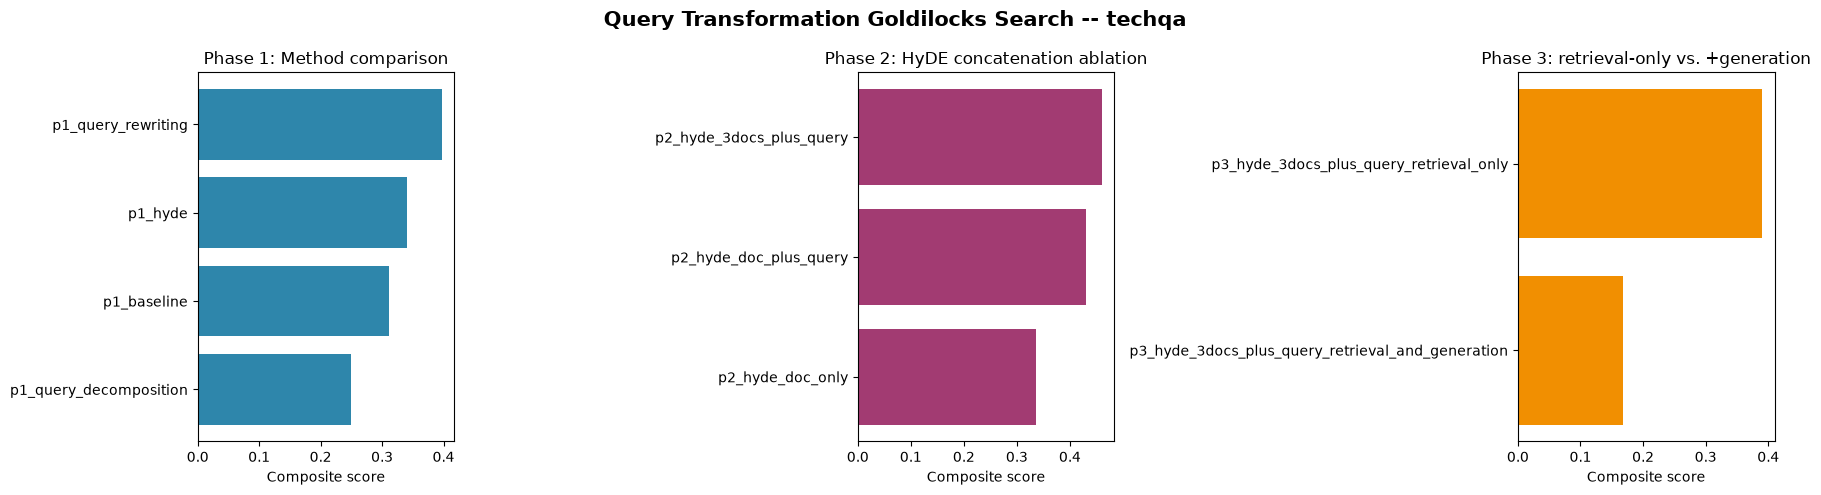

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(f"Query Transformation Goldilocks Search -- {DATASET_NAME}", fontsize=15, fontweight="bold")

p1_plot = phase1_df.dropna(subset=["composite"]).sort_values("composite")
axes[0].barh(p1_plot["config"], p1_plot["composite"], color="#2E86AB")
axes[0].set_xlabel("Composite score")
axes[0].set_title("Phase 1: Method comparison")

p2_plot = phase2_df.dropna(subset=["composite"]).sort_values("composite")
axes[1].barh(p2_plot["config"], p2_plot["composite"], color="#A23B72")
axes[1].set_xlabel("Composite score")
axes[1].set_title("Phase 2: HyDE concatenation ablation")

if not phase3_df.empty:
    p3_plot = phase3_df.dropna(subset=["composite"]).sort_values("composite")
    axes[2].barh(p3_plot["config"], p3_plot["composite"], color="#F18F01")
    axes[2].set_xlabel("Composite score")
    axes[2].set_title("Phase 3: retrieval-only vs. +generation")
else:
    axes[2].axis("off")
    axes[2].set_title("Phase 3: skipped")

plt.tight_layout()
plt.show()


## Step 12: Final Recommendation

In [12]:
all_results_df = pd.concat([phase1_df, phase2_df, phase3_df], ignore_index=True)
all_results_df = all_results_df.dropna(subset=["composite"]).sort_values("composite", ascending=False)

print("=" * 100)
print("ALL CONFIGS ACROSS ALL PHASES, RANKED BY COMPOSITE SCORE")
print("=" * 100)
display(all_results_df[[
    "config", "n_eval", "n_failed",
    "context_relevance", "utilization", "completeness", "adherence", "composite",
]])

best = all_results_df.iloc[0]
baseline_row = phase1_df[phase1_df["config"] == "p1_baseline"].iloc[0]

print("\n" + "=" * 100)
print(f"🏆 GOLDILOCKS QUERY-TRANSFORMATION CONFIG: {best['config']}")
print("=" * 100)
print(f"  Context Relevance:  {best['context_relevance']:.4f}")
print(f"  Utilization:        {best['utilization']:.4f}")
print(f"  Completeness:       {best['completeness']:.4f}")
print(f"  Adherence:          {best['adherence']:.4f}")
print(f"  Composite:          {best['composite']:.4f}")
print(f"  Eval sample:        {best['n_eval']}/{EVAL_SAMPLE_SIZE} succeeded (failed: {best['n_failed']})")
if baseline_row["composite"] is not None and best["config"] != "p1_baseline":
    delta = best["composite"] - baseline_row["composite"]
    print(f"  vs. no-transformation baseline: {delta:+.4f} composite ({'worth adopting' if delta > 0 else 'baseline still wins'})")
print("=" * 100)


ALL CONFIGS ACROSS ALL PHASES, RANKED BY COMPOSITE SCORE


,config,n_eval,n_failed,context_relevance,utilization,completeness,adherence,composite
4,p2_hyde_3docs_plus_query,20,0,0.322655,0.168745,0.518470,0.70,0.461011
5,p2_hyde_doc_plus_query,20,0,0.292695,0.177745,0.612085,0.60,0.430918
0,p1_query_rewriting,20,0,0.284025,0.165700,0.540475,0.55,0.397835
7,p3_hyde_3docs_plus_query_retrieval_only,20,0,0.346080,0.139620,0.489740,0.50,0.390532
1,p1_hyde,20,0,0.287190,0.091185,0.340410,0.50,0.340256
6,p2_hyde_doc_only,20,0,0.381025,0.179730,0.351325,0.35,0.335517
2,p1_baseline,20,0,0.272995,0.097260,0.291905,0.45,0.311423
3,p1_query_decomposition,20,0,0.238920,0.111775,0.414165,0.25,0.250013
8,p3_hyde_3docs_plus_query_retrieval_and_generation,20,0,0.216840,0.029255,0.118330,0.20,0.168032



🏆 GOLDILOCKS QUERY-TRANSFORMATION CONFIG: p2_hyde_3docs_plus_query
  Context Relevance:  0.3227
  Utilization:        0.1687
  Completeness:       0.5185
  Adherence:          0.7000
  Composite:          0.4610
  Eval sample:        20/20 succeeded (failed: 0)
  vs. no-transformation baseline: +0.1496 composite (worth adopting)


### Caveats -- read before treating this as final

- **Still a single run on one fixed 20-question sample.** Retrying failed annotations and
  reusing the same question set across every config removes some noise, but this is one
  dataset draw.
- **Chunking and retriever held constant** at `11`'s and `12`'s winning configs. Whether a
  different chunking/retriever pairing would change which transformation wins is not
  explored here.
- **`query_llm` (temperature 0.7) is stochastic** -- HyDE and decomposition outputs vary
  run to run even with the same question, unlike the deterministic chunking/retriever
  configs in `11`/`12`. A repeat run could shuffle Phase 1/2's close results.
- **Phase 3 only ever tests one transformation method** (the best non-baseline performer
  from Phases 1-2). If that method is a weak performer overall, the retrieval-vs-generation
  ablation result doesn't necessarily generalize to the other methods.
- **Embedding model, generator, and judge models held constant** across every notebook in
  this series. Not explored as variables here.
- **Composite score weighting (0.35/0.15/0.15/0.35) is a judgment call**, kept identical to
  `11`/`12` for comparability. The raw per-metric columns are in every results table if you
  want to re-rank by a different weighting or a single metric.
